In [16]:
funnel = pd.DataFrame({
    "stage": [
        "Visited",
        "Signed Up",
        "Verified",
        "Funded",
        "Active"
    ],
    "users": [
        df["visited"].sum(),
        df["signed_up"].sum(),
        df["verified"].sum(),
        df["funded"].sum(),
        df["active"].sum()
    ]
})

funnel["conversion_rate"] = (
    funnel["users"] / funnel.loc[0, "users"] * 100
).round(2)

funnel["drop_off_rate"] = (
    100 - funnel["users"].div(funnel["users"].shift(1)) * 100
).round(2)

funnel

,stage,users,conversion_rate,drop_off_rate
0,Visited,5000,100.00,NaN
1,Signed Up,3279,65.58,34.42
2,Verified,2457,49.14,25.07
3,Funded,1460,29.20,40.58
4,Active,1173,23.46,19.66


In [17]:
channel_analysis = (
    df.groupby("acquisition_channel")
    .agg(
        users=("user_id", "count"),
        signed_up=("signed_up", "sum"),
        verified=("verified", "sum"),
        funded=("funded", "sum"),
        active=("active", "sum")
    )
)

channel_analysis["signup_rate"] = (
    channel_analysis["signed_up"] / channel_analysis["users"] * 100
).round(2)

channel_analysis["funding_rate"] = (
    channel_analysis["funded"] / channel_analysis["verified"] * 100
).round(2)

channel_analysis["activation_rate"] = (
    channel_analysis["active"] / channel_analysis["funded"] * 100
).round(2)

channel_analysis.sort_values("activation_rate", ascending=False)

,users,signed_up,verified,funded,active,signup_rate,funding_rate,activation_rate
acquisition_channel,,,,,,,,
Paid Search,1032,668,510,277,232,64.73,54.31,83.75
Referral,1007,670,499,299,244,66.53,59.92,81.61
Email,965,639,467,285,229,66.22,61.03,80.35
Organic,1025,675,515,302,239,65.85,58.64,79.14
Social Media,971,627,466,297,229,64.57,63.73,77.10


In [18]:
df["month"] = df["event_date"].dt.to_period("M")

cohort = (
    df.groupby("month")
      .agg(
          users=("user_id", "count"),
          active=("active", "sum")
      )
)

cohort["activation_rate"] = (
    cohort["active"] / cohort["users"] * 100
).round(2)

cohort

,users,active,activation_rate
month,,,
2025-01,442,98,22.17
2025-02,404,87,21.53
2025-03,387,86,22.22
2025-04,388,96,24.74
2025-05,430,90,20.93
2025-06,386,92,23.83
2025-07,440,110,25.00
2025-08,408,92,22.55
2025-09,434,102,23.50


         users  active  activation_rate
variant                                
A         2504     601            24.00
B         2496     572            22.92


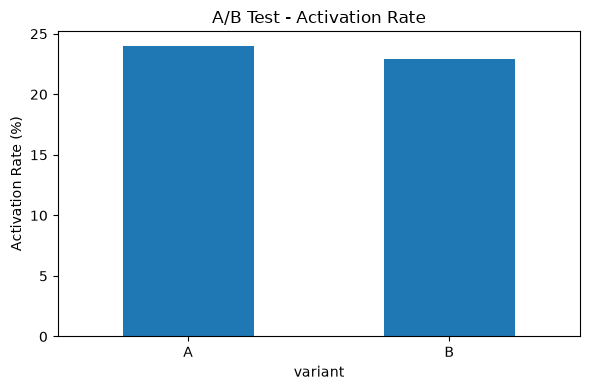

In [19]:
np.random.seed(42)

df["variant"] = np.random.choice(
    ["A", "B"],
    size=len(df)
)

ab_test = (
    df.groupby("variant")
      .agg(
          users=("user_id", "count"),
          active=("active", "sum")
      )
)

ab_test["activation_rate"] = (
    ab_test["active"] / ab_test["users"] * 100
).round(2)

print(ab_test)

ab_test["activation_rate"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("A/B Test - Activation Rate")
plt.ylabel("Activation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
SELECT
    acquisition_channel,
    COUNT(*) AS users,
    SUM(active) AS active_users,
    ROUND(SUM(active)::numeric / COUNT(*) * 100,2) AS activation_rate
FROM funnel_users
GROUP BY acquisition_channel
ORDER BY activation_rate DESC;

SELECT
    country,
    COUNT(*) AS users,
    ROUND(AVG(active) * 100,2) AS activation_rate
FROM funnel_users
GROUP BY country
ORDER BY activation_rate DESC;

SELECT
    DATE_TRUNC('month', event_date) AS month,
    COUNT(*) AS users,
    SUM(active) AS active_users
FROM funnel_users
GROUP BY month
ORDER BY month;

IndentationError: unexpected indent (249330857.py, line 2)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/funnel_users.csv")

df["event_date"] = pd.to_datetime(df["event_date"])

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (5000, 9)


,user_id,event_date,country,acquisition_channel,visited,signed_up,verified,funded,active
0,1,2025-11-24,Senegal,Organic,1,0,0,0,0
1,2,2025-05-06,France,Paid Search,1,0,0,0,0
2,3,2025-12-13,Portugal,Email,1,1,1,1,1
3,4,2025-09-16,Spain,Organic,1,1,1,0,0
4,5,2025-08-03,France,Referral,1,1,0,0,0
